# Municipal Budgets Exploration (2023)

This notebook explores the municipal budget data from [Gobierto Budgets Data](https://github.com/PopulateTools/gobierto-budgets-data).
We are focusing on the **2023 planned budget** for Madrid, Barcelona, and Sevilla using our compiled CSV.

In [6]:
import pandas as pd
import requests
import gzip
from io import BytesIO
import re
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Configuration & Data Loading

In [7]:
print("Loading the extracted 2023 dataset...")
df_budgets = pd.read_csv('../data/municipal_budgets_2023.csv')

# Only keep planned budgets for Madrid, Barcelona, and Sevilla
df_target = df_budgets[(df_budgets['year'] == 2023) & 
                       (df_budgets['type'] == 'planned') & 
                       (df_budgets['city'].isin(['Madrid', 'Barcelona', 'Sevilla']))]

TARGET_CITIES = ['Madrid', 'Barcelona', 'Sevilla']

# Fast function to extract dictionary mapping from Gobierto SQL
def get_names_mapping(url, table_name, id_col, name_col):
    r = requests.get(url, stream=True)
    mapping = {}
    content = BytesIO(r.content)
    with gzip.GzipFile(fileobj=content) as f:
        for line in f:
            line = line.decode('utf-8', errors='replace')
            if line.startswith(f'INSERT INTO "{table_name}"'):
                match = re.search(r'VALUES \((.*)\);', line)
                if match:
                    parts = re.findall(r"'[^']*'|[^,]+", match.group(1))
                    vals = [v.strip(" '") for v in parts]
                    if len(vals) >= max(id_col, name_col) + 1:
                        mapping[vals[id_col]] = vals[name_col]
    return mapping

print("Loading classification dictionaries from GitHub (2023)...")
econ_url = "https://raw.githubusercontent.com/PopulateTools/gobierto-budgets-data/master/data/presupuestos_municipales/2023/planned/tb_cuentasEconomica.sql.gz"
func_url = "https://raw.githubusercontent.com/PopulateTools/gobierto-budgets-data/master/data/presupuestos_municipales/2023/planned/tb_cuentasProgramas.sql.gz"

econ_chapter_map = get_names_mapping(econ_url, 'tb_cuentasEconomica', 1, 2)
func_map = get_names_mapping(func_url, 'tb_cuentasProgramas', 0, 1)

display(df_target.head())

Loading the extracted 2023 dataset...
Loading classification dictionaries from GitHub (2023)...


,year,type,city,classification,tipreig,code,amount
69,2023,planned,Barcelona,economic,G,212.0,15466778.44
70,2023,planned,Barcelona,economic,G,62.0,4232850.00
71,2023,planned,Barcelona,economic,G,635.0,1065000.00
72,2023,planned,Barcelona,economic,I,396.0,20.00
73,2023,planned,Barcelona,economic,G,110.0,7460246.66


# 2. Interactive Budget Dashboard (Selectable City & Subdivisions)
Select a city from the dropdown below to instantly re-render horizontal bar plots across all granularity levels.

In [8]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def plot_city_dashboard(city):
    clear_output(wait=True) # Clears the previous plots cleanly
    fig, axes = plt.subplots(3, 2, figsize=(20, 18))
    fig.suptitle(f'2023 Planned Budget Analysis Dashboard: {city}', fontsize=20, weight='bold')

    city_data = df_target[df_target['city'] == city]
    df_econ = city_data[(city_data['classification'] == 'economic') & (city_data['tipreig'] == 'G')]
    df_func = city_data[(city_data['classification'] == 'functional') & (city_data['tipreig'] == 'G')]
    
    levels = [
        ('Economic', df_econ, econ_chapter_map, 'mako'),
        ('Functional', df_func, func_map, 'viridis')
    ]
    
    for col, (name, df, mapping, palette) in enumerate(levels):
        for row, max_digits in enumerate([1, 2, 3]):
            df_g = df.copy()
            # 1-digit (Chapter/Policy Area), 2-digit (Article/Policy), 3-digit (Concept/Program)
            df_g['level_code'] = df_g['code'].astype(int).astype(str).str[:max_digits]
            grouped = df_g.groupby('level_code')['amount'].sum().reset_index()
            grouped['Category'] = grouped['level_code'].map(mapping).fillna(grouped['level_code'])
            # Top 10 for displaying cleanly horizontally
            grouped = grouped.sort_values(by='amount', ascending=False).head(10)
            
            ax = axes[row, col]
            sns.barplot(data=grouped, x='amount', y='Category', ax=ax, palette=palette, hue='Category', legend=False)
            level_names = ['Chapter / Area (1-digit)', 'Article / Policy (2-digit)', 'Concept / Program (3-digit)']
            ax.set_title(f'{name} {level_names[row]}')
            ax.set_xlabel('Amount (€)')
            ax.set_ylabel('')

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

dropdown = widgets.Dropdown(options=TARGET_CITIES, value='Madrid', description='Select City:')
widgets.interact(plot_city_dashboard, city=dropdown);

interactive(children=(Dropdown(description='Select City:', options=('Madrid', 'Barcelona', 'Sevilla'), value='…

# 3. BikesForCities: Advanced Mobility Investment Analysis
As a modern mobility application, we are uniquely interested in how cities allocate funding between **Sustainable Public/Active Mobility** vs **Traditional Car/Traffic Infrastructure**.

We will isolate 3-digit Functional Programs:
- **Sustainable Mobility**: `134` (Urban Mobility), `441` (Passenger Transport), `442` (Transport Infrastructure)
- **Traditional Traffic/Logistics**: `133` (Traffic/Parking Management), `453` (Highways/Roads), `153` (Public Street Paving)

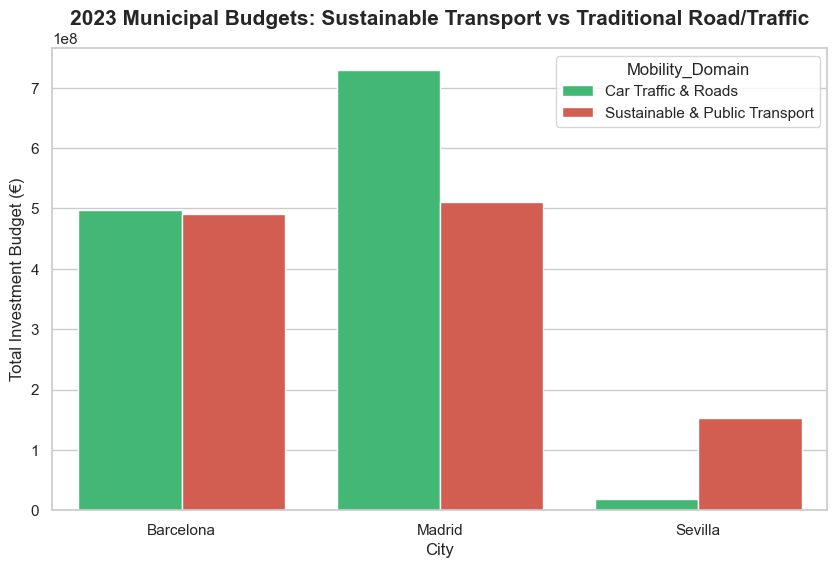

Mobility_Domain,Mobility Sustainability Score (%)
city,
Sevilla,89.380705
Barcelona,49.683038
Madrid,41.227299


In [9]:
# Define mobility functional domains
sustainable_codes = ['134', '441', '442']
car_codes = ['133', '453', '153']

df_func_all = df_target[(df_target['classification'] == 'functional') & (df_target['tipreig'] == 'G')].copy()
df_func_all['program_code'] = df_func_all['code'].astype(int).astype(str).str[:3]

# Categorize spending
def categorize_mobility(code):
    if code in sustainable_codes: return 'Sustainable & Public Transport'
    if code in car_codes: return 'Car Traffic & Roads'
    return 'Other Municipal'

df_func_all['Mobility_Domain'] = df_func_all['program_code'].apply(categorize_mobility)
df_mobility = df_func_all[df_func_all['Mobility_Domain'] != 'Other Municipal']

# Aggregate by city and domain
mob_grouped = df_mobility.groupby(['city', 'Mobility_Domain'])['amount'].sum().reset_index()

# Visualize Domain Comparison!
plt.figure(figsize=(10, 6))
sns.barplot(data=mob_grouped, x='city', y='amount', hue='Mobility_Domain', palette=['#2ECC71', '#E74C3C'])
plt.title('2023 Municipal Budgets: Sustainable Transport vs Traditional Road/Traffic', fontsize=15, weight='bold')
plt.xlabel('City')
plt.ylabel('Total Investment Budget (€)')
plt.show()

# Calculate % Ratios
pivot = mob_grouped.pivot(index='city', columns='Mobility_Domain', values='amount').fillna(0)
pivot['Mobility Sustainability Score (%)'] = (pivot['Sustainable & Public Transport'] / 
                                              (pivot['Sustainable & Public Transport'] + pivot['Car Traffic & Roads']) * 100)
display(pivot[['Mobility Sustainability Score (%)']].sort_values(by='Mobility Sustainability Score (%)', ascending=False))

# 4. Budget Hierarchy Visualization (Sunburst)
A Sunburst plot provides an intuitive way to explore the budget hierarchy, drilling down from Chapter to Article and into Concepts.

In [11]:
import plotly.express as px

# We use Barcelona as a primary visual example
df_sun = df_target[(df_target['city'] == 'Barcelona') & 
                   (df_target['classification'] == 'economic') & 
                   (df_target['tipreig'] == 'G')].copy()

# Ensure string and remove '.0'
df_sun['code_str'] = df_sun['code'].astype(str).str.replace(r'\.0$', '', regex=True)

# Build bulletproof distinct hierarchy paths using code length explicitly
def get_l1(x): 
    return f"{x[:1]} - {econ_chapter_map.get(x[:1], 'Unknown')}"

def get_l2(x): 
    if len(x) >= 2:
        return f"{x[:2]} - {econ_chapter_map.get(x[:2], 'Unknown')}"
    return f"(General) {econ_chapter_map.get(x[:1], 'Unknown')}"

def get_l3(x): 
    if len(x) >= 3:
        return f"{x[:3]} - {econ_chapter_map.get(x[:3], 'Unknown')}"
    if len(x) == 2:
        return f"(General) {econ_chapter_map.get(x[:2], 'Unknown')}"
    return f"(General) {econ_chapter_map.get(x[:1], 'Unknown')}"

df_sun['Chapter (L1)'] = df_sun['code_str'].apply(get_l1)
df_sun['Article (L2)'] = df_sun['code_str'].apply(get_l2)
df_sun['Concept (L3)'] = df_sun['code_str'].apply(get_l3)

# Aggregate cleanly to ensure pure unique leaves
df_agg = df_sun.groupby(['Chapter (L1)', 'Article (L2)', 'Concept (L3)'])['amount'].sum().reset_index()
df_agg = df_agg[df_agg['amount'] > 0]

fig = px.sunburst(
    df_agg,
    path=['Chapter (L1)', 'Article (L2)', 'Concept (L3)'],
    values='amount',
    title='Barcelona 2023 Planned Budget: Complete Economic Hierarchy',
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(width=900, height=900)
fig.update_traces(textinfo='label+percent parent')
fig.show()